# 1 - Simple Pitch Analysis of Jazz Corpus

## Imports

In [162]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [164]:
%reload_ext autoreload
%matplotlib inline
import pandas as pd
from fractions import Fraction
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
import music21 as m21
import io
from PIL import Image

In [166]:
import warnings

# Suppress all warnings
warnings.filterwarnings("ignore")

In [364]:
%reload_ext autoreload
import sys
sys.path.append('/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/')

from Importables import General as g
from Importables import pitchanalysis_utils as pa

## Load + Preprocess data

In [484]:
metadata = g.load_metadata()
metadata = metadata[metadata['recording_year'] >= 1950]

In [486]:
notes = g.load_notes(metadata, keys=True)
notes_year = g.bin_years(notes, 1950, 2020, 10)

In [487]:
notes[['pc', 'note', 'tpc', 'key']]

,pc,note,tpc,key
0,8,A-,-4,c minor
1,14,D,2,c minor
2,20,A-,-4,c minor
3,7,G,1,c minor
4,7,G,1,c minor
...,...,...,...,...
155571,9,A,3,F major
155572,12,C,0,F major
155573,17,F,-1,F major
155574,13,C#,7,F major


In [489]:
notes_C[['pc', 'note', 'tpc',  'key', 'old note']]

,pc,note,tpc,key,old note
0,8.0,A-,-4.0,c minor,A-
1,2.0,D,2.0,c minor,D
2,8.0,A-,-4.0,c minor,A-
3,7.0,G,1.0,c minor,G
4,7.0,G,1.0,c minor,G
...,...,...,...,...,...
155571,4.0,E,4.0,F major,A
155572,7.0,G,1.0,F major,C
155573,0.0,C,0.0,F major,F
155574,8.0,G#,8.0,F major,C#


In [488]:
notes_C = pa.transpose_to_C(notes)


In [494]:
notes_C = notes_C[notes_C['note'].notna()]
notes_C_year = g.bin_years(notes_C, 1950, 2020, 10)

## Tonnetz

### Original Key

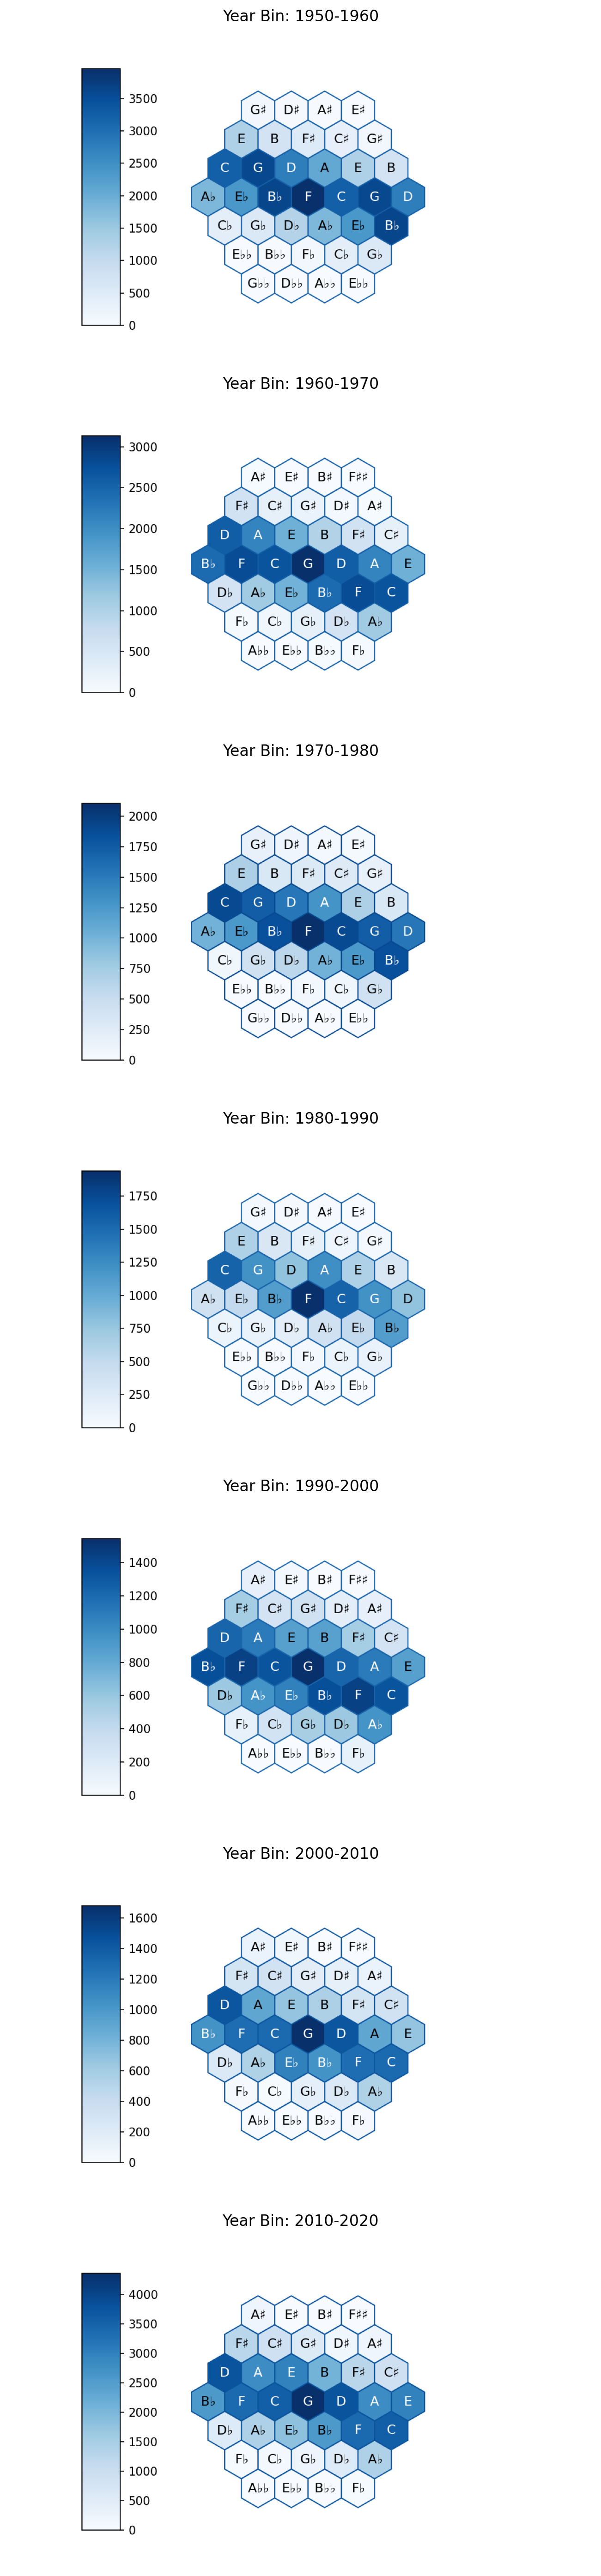

In [126]:
n_bins = len(bin_labels)
fig, axes = plt.subplots(n_bins, 1, figsize=(7, n_bins * 4))
if n_bins == 1:
    axes = [axes]  

for ax, years in zip(axes, bin_labels):
    notes_tonnetz = pd.DataFrame()
    df_years = metadata[metadata['year_bin'] == years]

    for _, row in df_years.iterrows():
        try:
            base_path = '/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/jazz_transcriptions/' 
            path = f"{base_path}{row['rel_paths']}/{row['fnames']}.xml"

            df = ppp.xml_to_csv(path, save_csv=False)
            notes_tonnetz = pd.concat([notes_tonnetz, df], ignore_index=True)

        except Exception:
            continue

    notes_tonnetz = notes_tonnetz.dropna(subset=['tpc'])
    notes_tonnetz['tpc'] = (notes_tonnetz['tpc'].str.replace('x', '##'))

    fig_tmp = pps.tonnetz(notes_tonnetz, show=False)

    buf = io.BytesIO()
    fig_tmp.savefig(buf, format='png', dpi=150)
    buf.seek(0)
    img = Image.open(buf)

    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"Year Bin: {years}", fontsize=12)

plt.tight_layout()
#plt.savefig("all_tonnetz.png", dpi=300)
plt.show()


### Pitch plots transposed to C

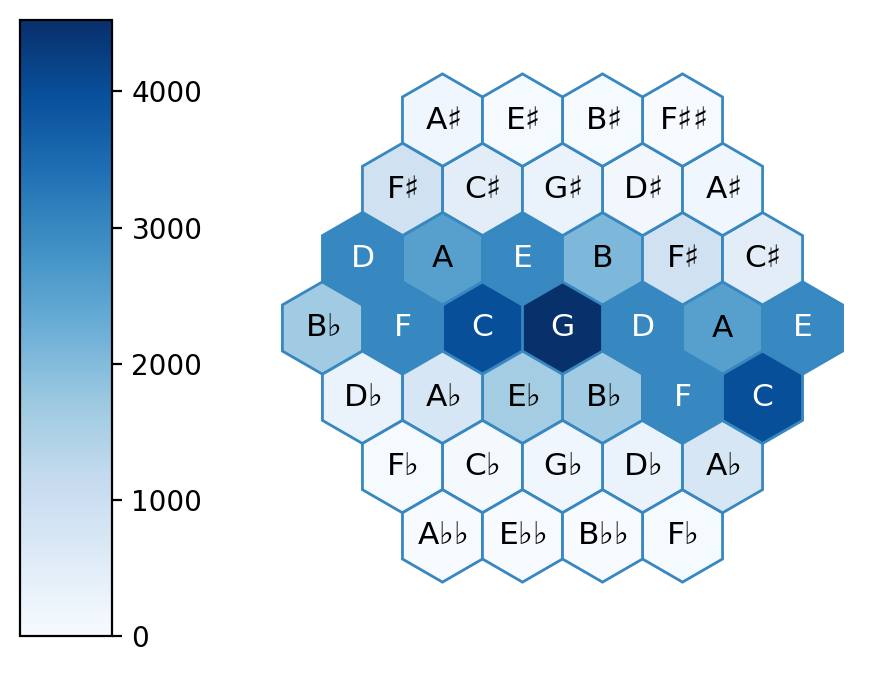

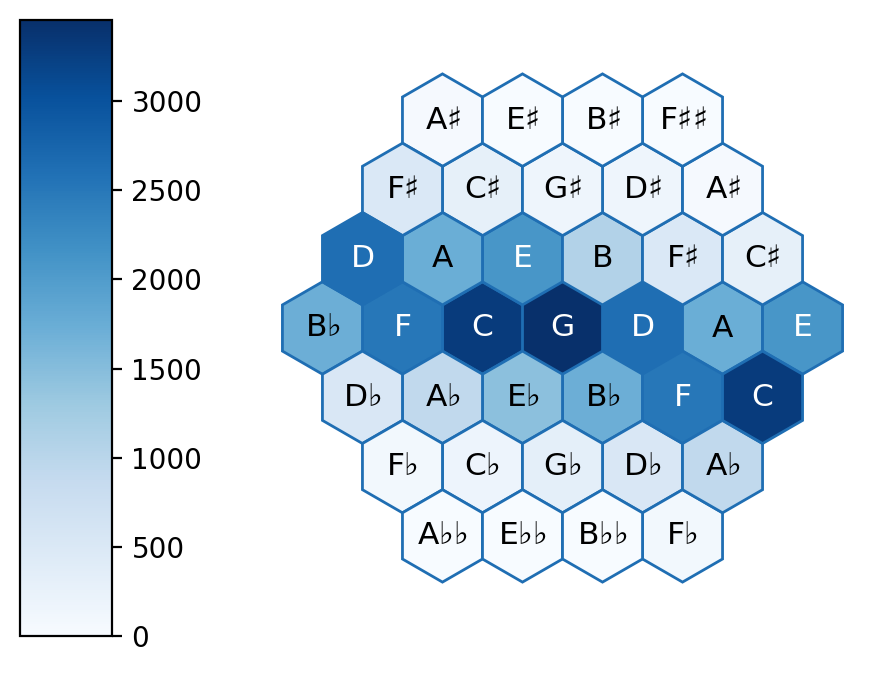

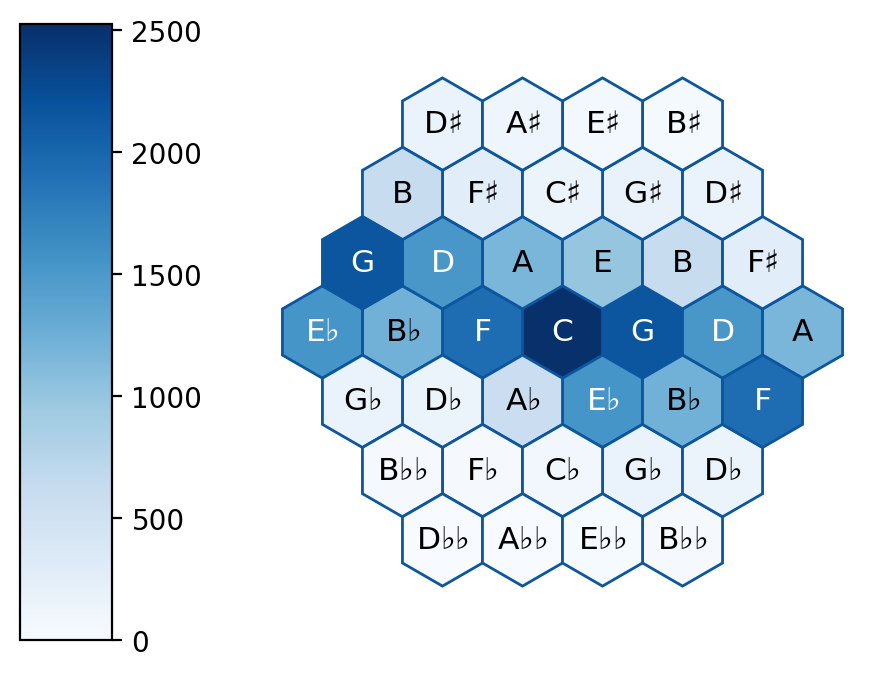

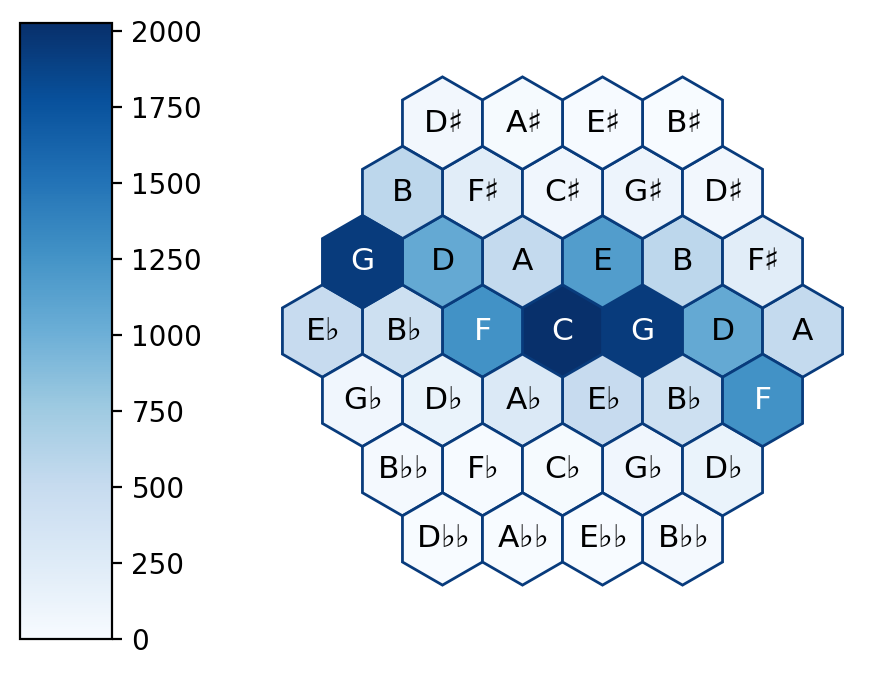

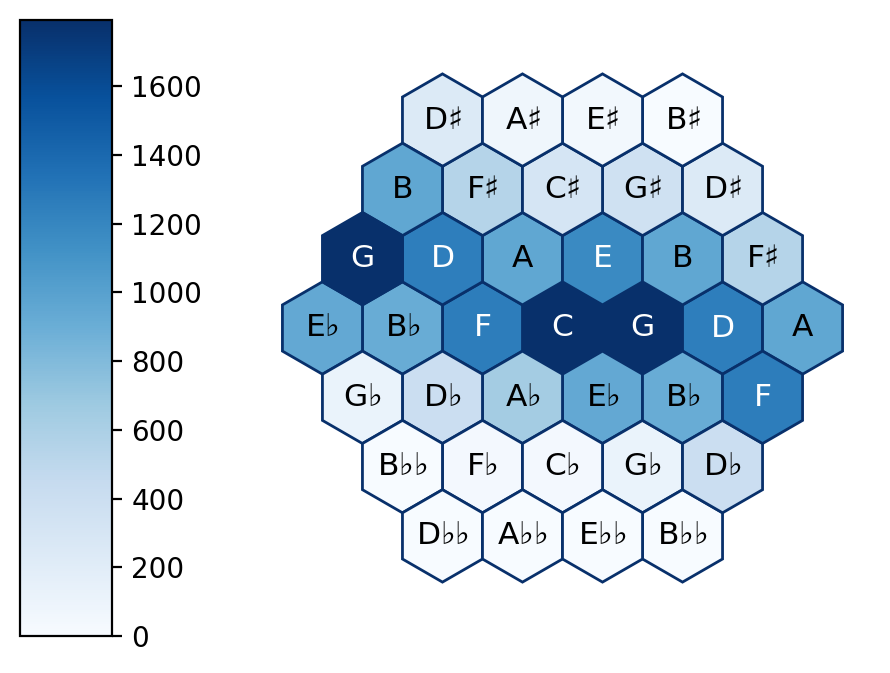

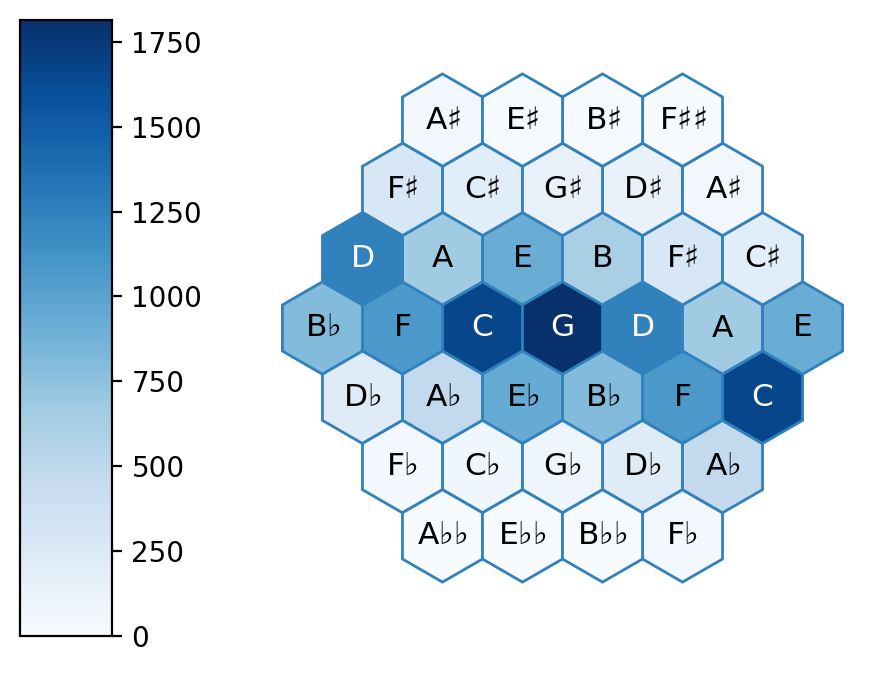

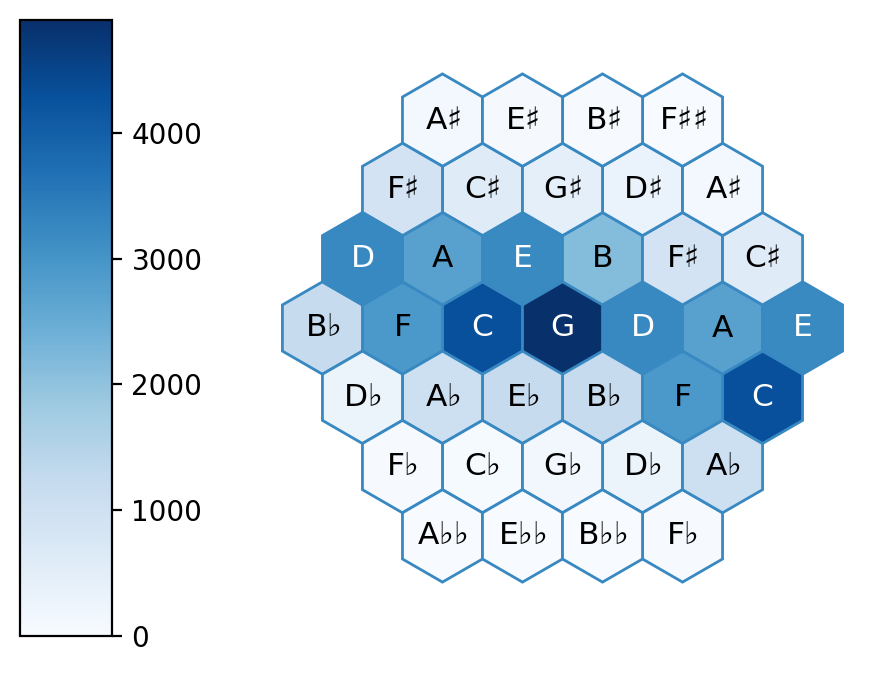

In [525]:
for years in bin_labels:
    notes_tonnetz = pd.DataFrame()
    df_years = metadata[metadata['year_bin'] == years]

    for _, row in df_years.iterrows():
        try: 
            base_path = '/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/jazz_transcriptions/' 
            path = base_path + row['rel_paths'] + '/' + row['fnames'] + '.xml'

            df = ppp.xml_to_csv(path, save_csv=False)

            score = m21.converter.parse(path)
            key = score.analyze('key')
            interval_to_c = m21.interval.Interval(key.tonic, m21.pitch.Pitch('C'))

            df['tpc'] = df['tpc'].str.replace('bb', '--', regex=False)
            df['tpc'] = df['tpc'].str.replace('bb', '--', regex=False)
            df['tpc'] = df['tpc'].apply(lambda n: m21.note.Note(n) if pd.notna(n) else np.nan)
            df['tpc'] = df['tpc'].apply(lambda n: n.transpose(interval_to_c) if pd.notna(n) else np.nan)
            df['tpc'] = df['tpc'].apply(lambda n: n.nameWithOctave if pd.notna(n) else np.nan)
            
            notes_tonnetz = pd.concat([notes_tonnetz, df[['tpc']]], ignore_index=True)
        except Exception as e:
            #print(f'{e}')
            continue

    notes_tonnetz = notes_tonnetz[notes_tonnetz['tpc'].notnull()]
    notes_tonnetz['tpc'] = notes_tonnetz['tpc'].apply(lambda note: note.replace('-', 'b'))
    notes_tonnetz['tpc'] = notes_tonnetz['tpc'].apply(lambda note: note.replace('--', 'bb'))
    notes_tonnetz['tpc'] = notes_tonnetz['tpc'].apply(lambda note: note.replace('---', 'bbb'))
    notes_tonnetz['tpc'] = notes_tonnetz['tpc'].apply(lambda note: note.replace('x', '##'))

    fig = pps.tonnetz(notes_tonnetz, show=True)
    fig.show()

## By Year

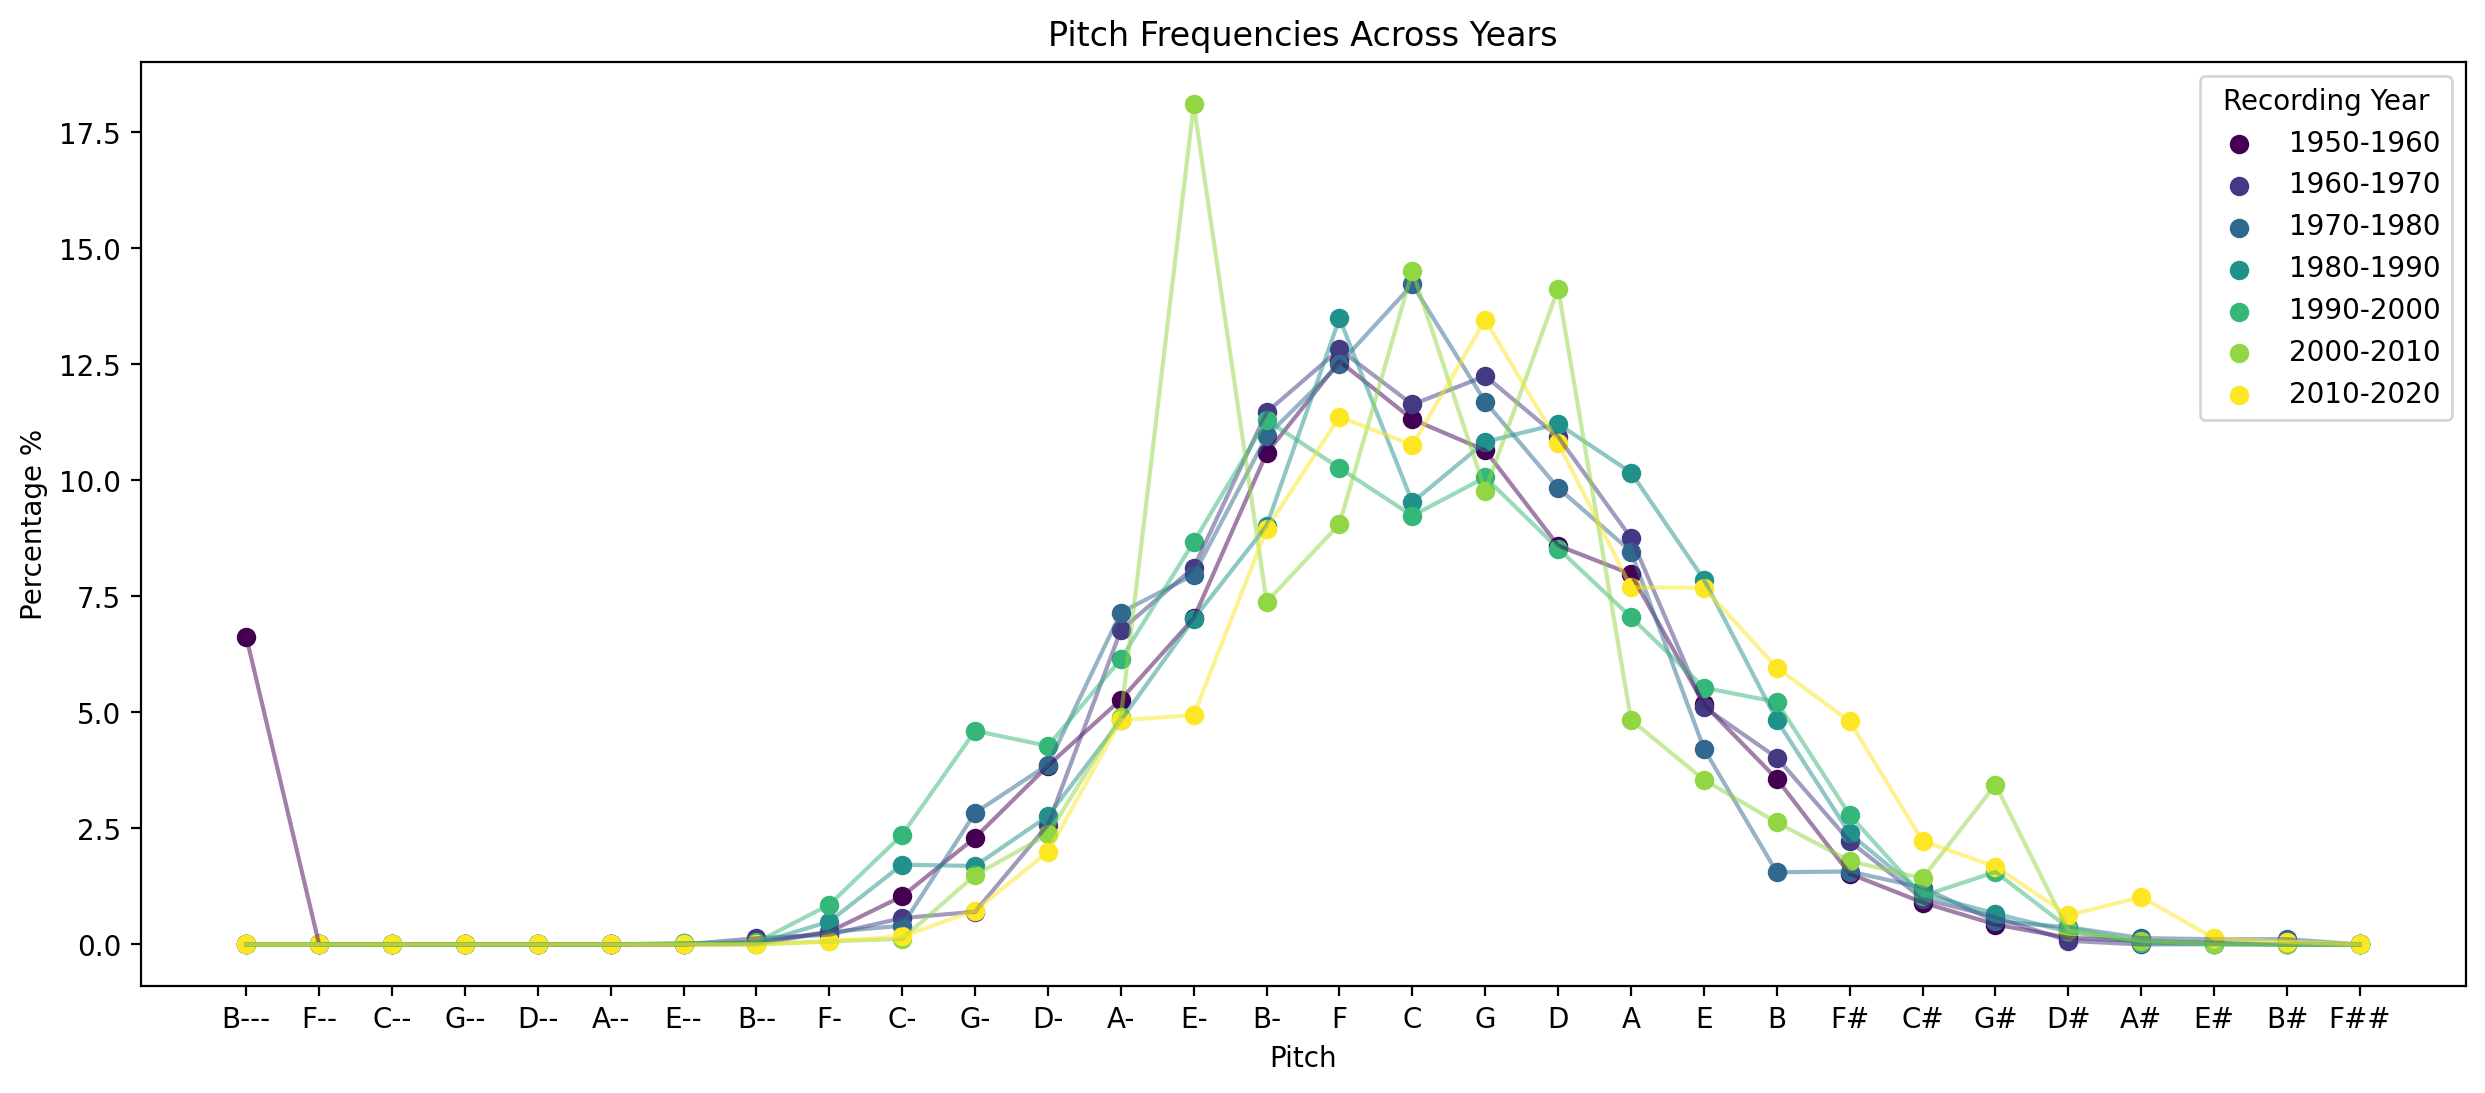

In [496]:
# Original keys
fig, ax = pa.plot_pitch_distribution(notes_year, 'Pitch Frequencies Across Years')
plt.show()  

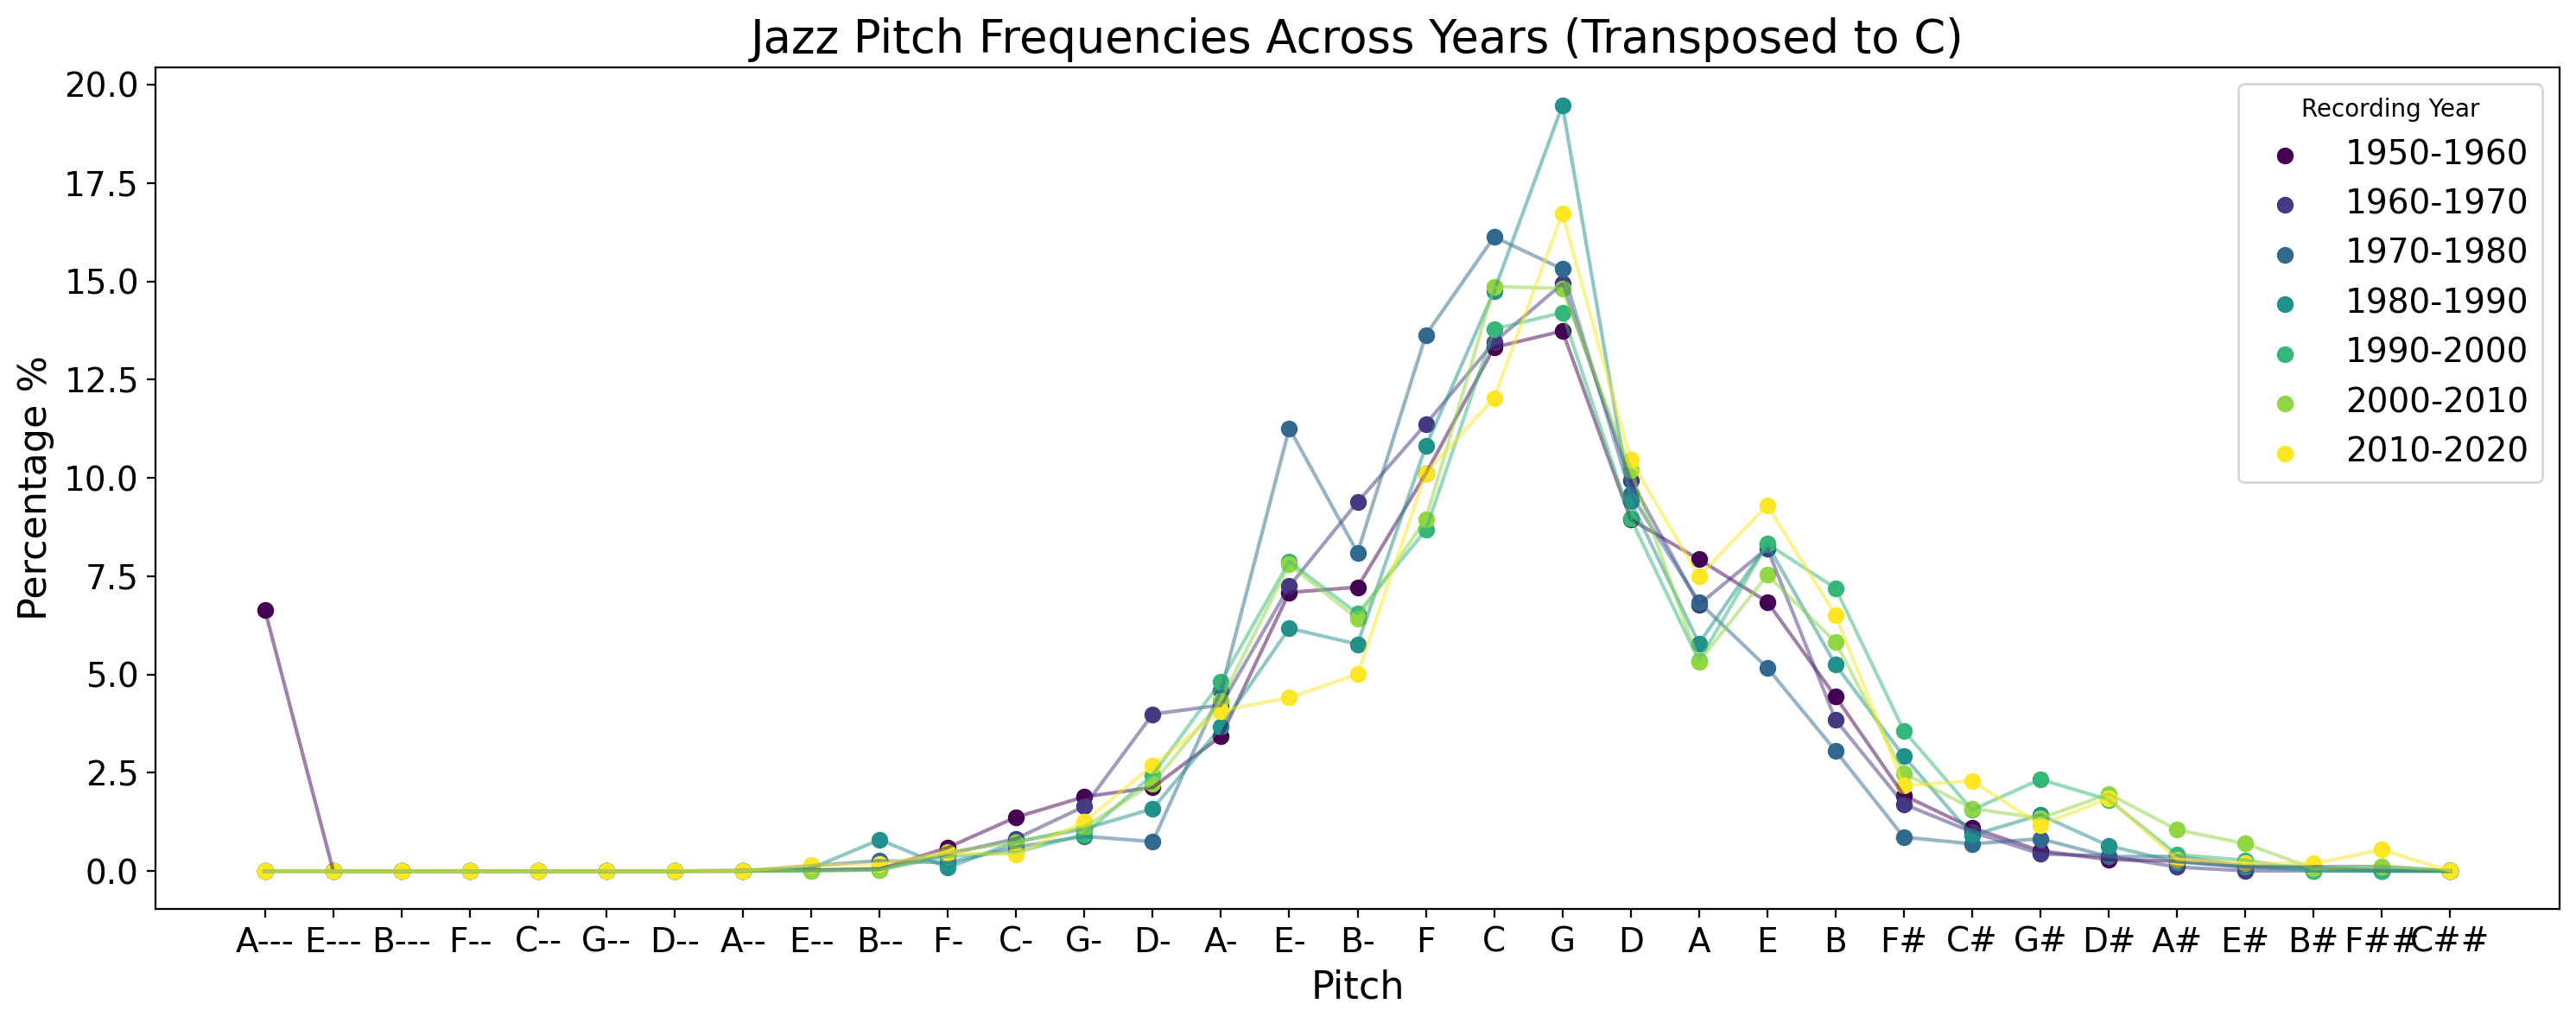

In [514]:
#Transposed to C
title = 'Jazz Pitch Frequencies Across Years (Transposed to C)'
fig, ax = pa.plot_pitch_distribution(notes_C_year, title)
plt.tight_layout()
plt.savefig(f'../Results/0823_YearPitchOverlay')
plt.show()  